In [1]:
# ============================================
# CELL 1: Libraries Import
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot style set karo — professional dikhna chahiye
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported!")

✅ All libraries imported!


In [31]:
# ============================================
# CELL 2: Data Load Karo
# ============================================
df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)

print("=" * 50)
print("📊 DATASET BASIC INFO")
print("=" * 50)
print(f"Total Rows    : {df.shape[0]:,}")
print(f"Total Columns : {df.shape[1]}")
print(f"Memory Usage  : {df.memory_usage().sum() / 1024**2:.3f} MB")

📊 DATASET BASIC INFO
Total Rows    : 150,000
Total Columns : 11
Memory Usage  : 13.733 MB


In [32]:
# ============================================
# CELL 3: Column Names Samjho
# ============================================

# WHY? Har column ka matlab samjhe bina
# feature engineering nahi kar sakte

column_meanings = {
    'SeriousDlqin2yrs'                        : '🎯 TARGET: 1=Default, 0=No Default',
    'RevolvingUtilizationOfUnsecuredLines'    : 'Credit card use % (0 to 1+)',
    'age'                                      : 'Age of borrower',
    'NumberOfTime30-59DaysPastDueNotWorse'    : 'Kitni baar 30-59 din late payment',
    'DebtRatio'                                : 'Monthly debt / Monthly income',
    'MonthlyIncome'                            : 'Monthly income in dollars',
    'NumberOfOpenCreditLinesAndLoans'         : 'Total open loans/credit cards',
    'NumberOfTimes90DaysLate'                 : 'Kitni baar 90+ din late',
    'NumberRealEstateLoansOrLines'            : 'Property loans count',
    'NumberOfTime60-89DaysPastDueNotWorse'    : 'Kitni baar 60-89 din late',
    'NumberOfDependents'                      : 'Family members dependent on borrower'
}

print("\n📖 COLUMN MEANINGS:")
print("-" * 60)
for col, meaning in column_meanings.items():
    print(f"{col:<45} → {meaning}")


📖 COLUMN MEANINGS:
------------------------------------------------------------
SeriousDlqin2yrs                              → 🎯 TARGET: 1=Default, 0=No Default
RevolvingUtilizationOfUnsecuredLines          → Credit card use % (0 to 1+)
age                                           → Age of borrower
NumberOfTime30-59DaysPastDueNotWorse          → Kitni baar 30-59 din late payment
DebtRatio                                     → Monthly debt / Monthly income
MonthlyIncome                                 → Monthly income in dollars
NumberOfOpenCreditLinesAndLoans               → Total open loans/credit cards
NumberOfTimes90DaysLate                       → Kitni baar 90+ din late
NumberRealEstateLoansOrLines                  → Property loans count
NumberOfTime60-89DaysPastDueNotWorse          → Kitni baar 60-89 din late
NumberOfDependents                            → Family members dependent on borrower


In [33]:
# ============================================
# CELL 4: Data Types aur Basic Stats
# ============================================
print("\n📋 DATA TYPES:")
print(df.dtypes)

print("\n📊 STATISTICAL SUMMARY:")
df.describe().T  # .T = transpose, reading easy hoti hai


📋 DATA TYPES:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

📊 STATISTICAL SUMMARY:


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


🚨 MISSING VALUES REPORT:
                    Missing Count  Missing % Data Type
MonthlyIncome               29731      19.82   float64
NumberOfDependents           3924       2.62   float64


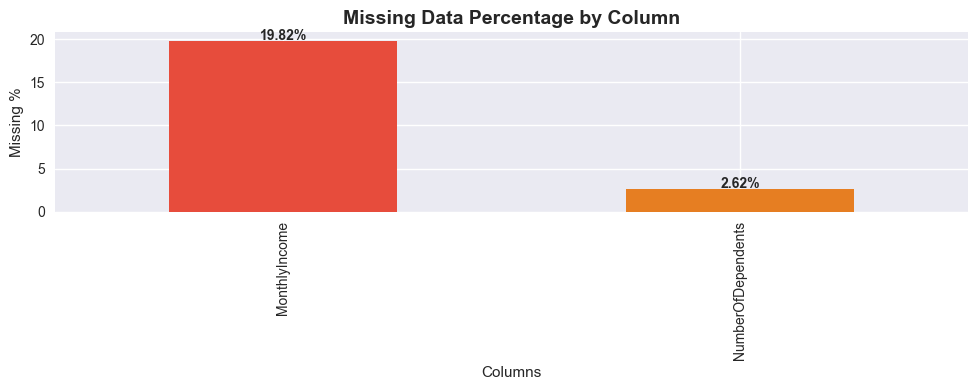

In [34]:
# ============================================
# CELL 5: Missing Values — CRITICAL CHECK
# ============================================

# WHY important?
# ML models NaN values handle nahi kar sakte directly
# Missing data strategy decide karni padti hai

missing = pd.DataFrame({
    'Missing Count'   : df.isnull().sum(),
    'Missing %'       : (df.isnull().sum() / len(df) * 100).round(2),
    'Data Type'       : df.dtypes
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("🚨 MISSING VALUES REPORT:")
print(missing)

# Visual representation
fig, ax = plt.subplots(figsize=(10, 4))
missing['Missing %'].plot(kind='bar', color=['#e74c3c', '#e67e22'], ax=ax)
ax.set_title('Missing Data Percentage by Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('Columns')

for i, v in enumerate(missing['Missing %']):
    ax.text(i, v + 0.1, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/missing_values.png', dpi=150)
plt.show()

# -----------------------------------------------
# Expected Output:
# MonthlyIncome     → ~29% missing  ← MAJOR issue
# NumberOfDependents→ ~2.6% missing ← Minor issue
# -----------------------------------------------

🎯 TARGET VARIABLE DISTRIBUTION:
Non-Default (0): 139,974 (93.3%)
Default     (1): 10,026 (6.7%)

Imbalance Ratio: 14.0:1


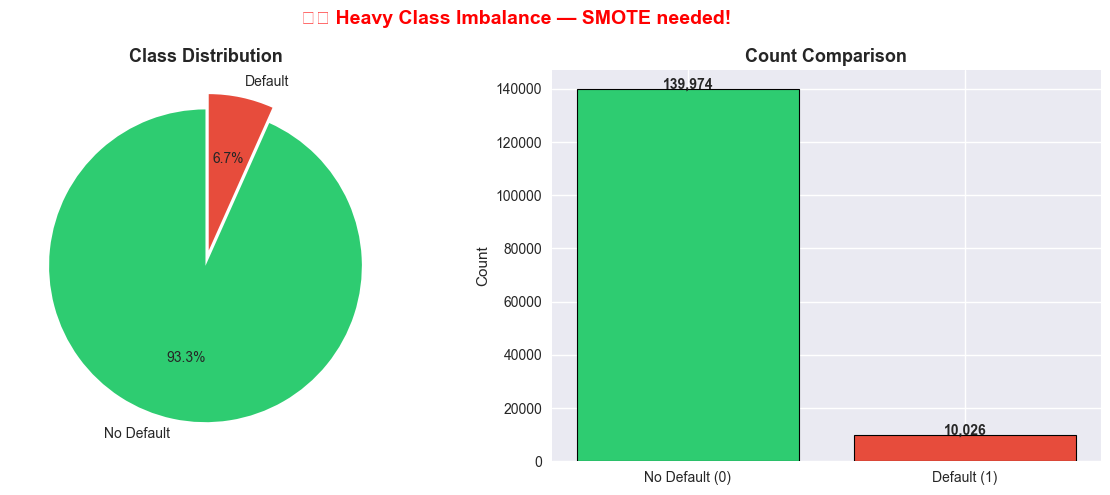

In [6]:
# ============================================
# CELL 6: TARGET VARIABLE — Class Imbalance
# ============================================

# WHY check karna zaroori hai?
# Agar 95% non-default hai, model sirf
# "no default" predict karega aur 95% accurate
# dikhega — yeh CHEATING hai!

target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct    = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print("🎯 TARGET VARIABLE DISTRIBUTION:")
print(f"Non-Default (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"Default     (1): {target_counts[1]:,} ({target_pct[1]:.1f}%)")
print(f"\nImbalance Ratio: {target_counts[0]/target_counts[1]:.1f}:1")

# Pie Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie
colors = ['#2ecc71', '#e74c3c']
ax1.pie(
    target_counts,
    labels=['No Default', 'Default'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.1)   # Default slice ko thoda alag karo
)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')

# Bar
ax2.bar(['No Default (0)', 'Default (1)'],
        target_counts.values,
        color=colors, edgecolor='black', linewidth=0.8)
ax2.set_title('Count Comparison', fontsize=13, fontweight='bold')
ax2.set_ylabel('Count')

for i, v in enumerate(target_counts.values):
    ax2.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('⚠️ Heavy Class Imbalance — SMOTE needed!',
             fontsize=14, color='red', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/class_imbalance.png', dpi=150)
plt.show()

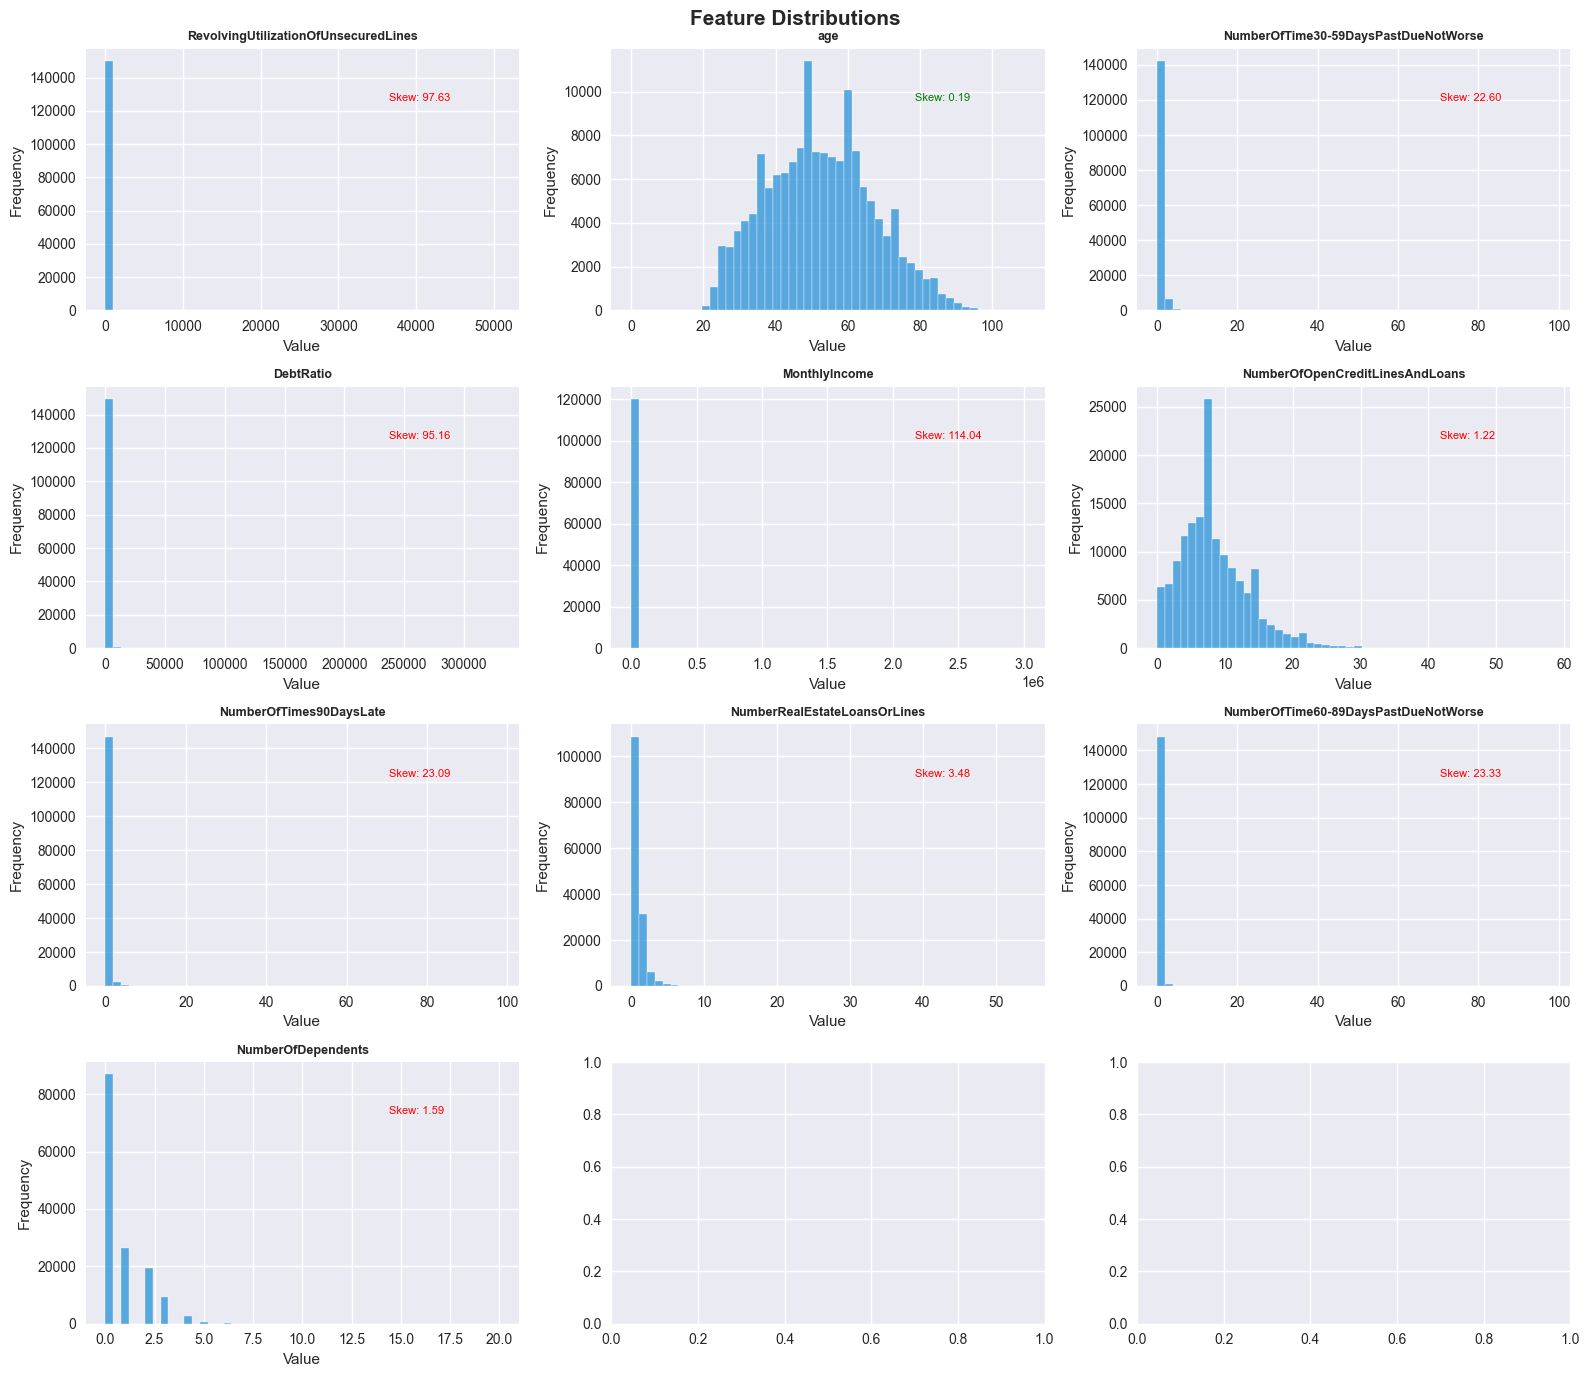

In [10]:
# ============================================
# CELL 7: Feature Distributions
# ============================================

# WHY? Distribution dekh ke pata chalta hai:
# - Normal hai ya skewed?
# - Outliers hain?
# - Transformation needed hai?

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('SeriousDlqin2yrs')  # Target hatao

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(
        df[col].dropna(),
        bins=50,
        color='#3498db',
        edgecolor='white',
        alpha=0.8
    )
    axes[i].set_title(f'{col}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

    # Skewness value show karo
    skew = df[col].skew()
    axes[i].text(
        0.7, 0.8, f'Skew: {skew:.2f}',
        transform=axes[i].transAxes,
        fontsize=8,
        color='red' if abs(skew) > 1 else 'green'
    )

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/distributions.png', dpi=150)
plt.show()

# -----------------------------------------------
# Observation:
# MonthlyIncome       → Highly right skewed (log transform needed)
# DebtRatio           → Extreme outliers hain
# Age                 → Roughly normal ✅
# Late payment cols   → Most values are 0 (sparse)
# -----------------------------------------------

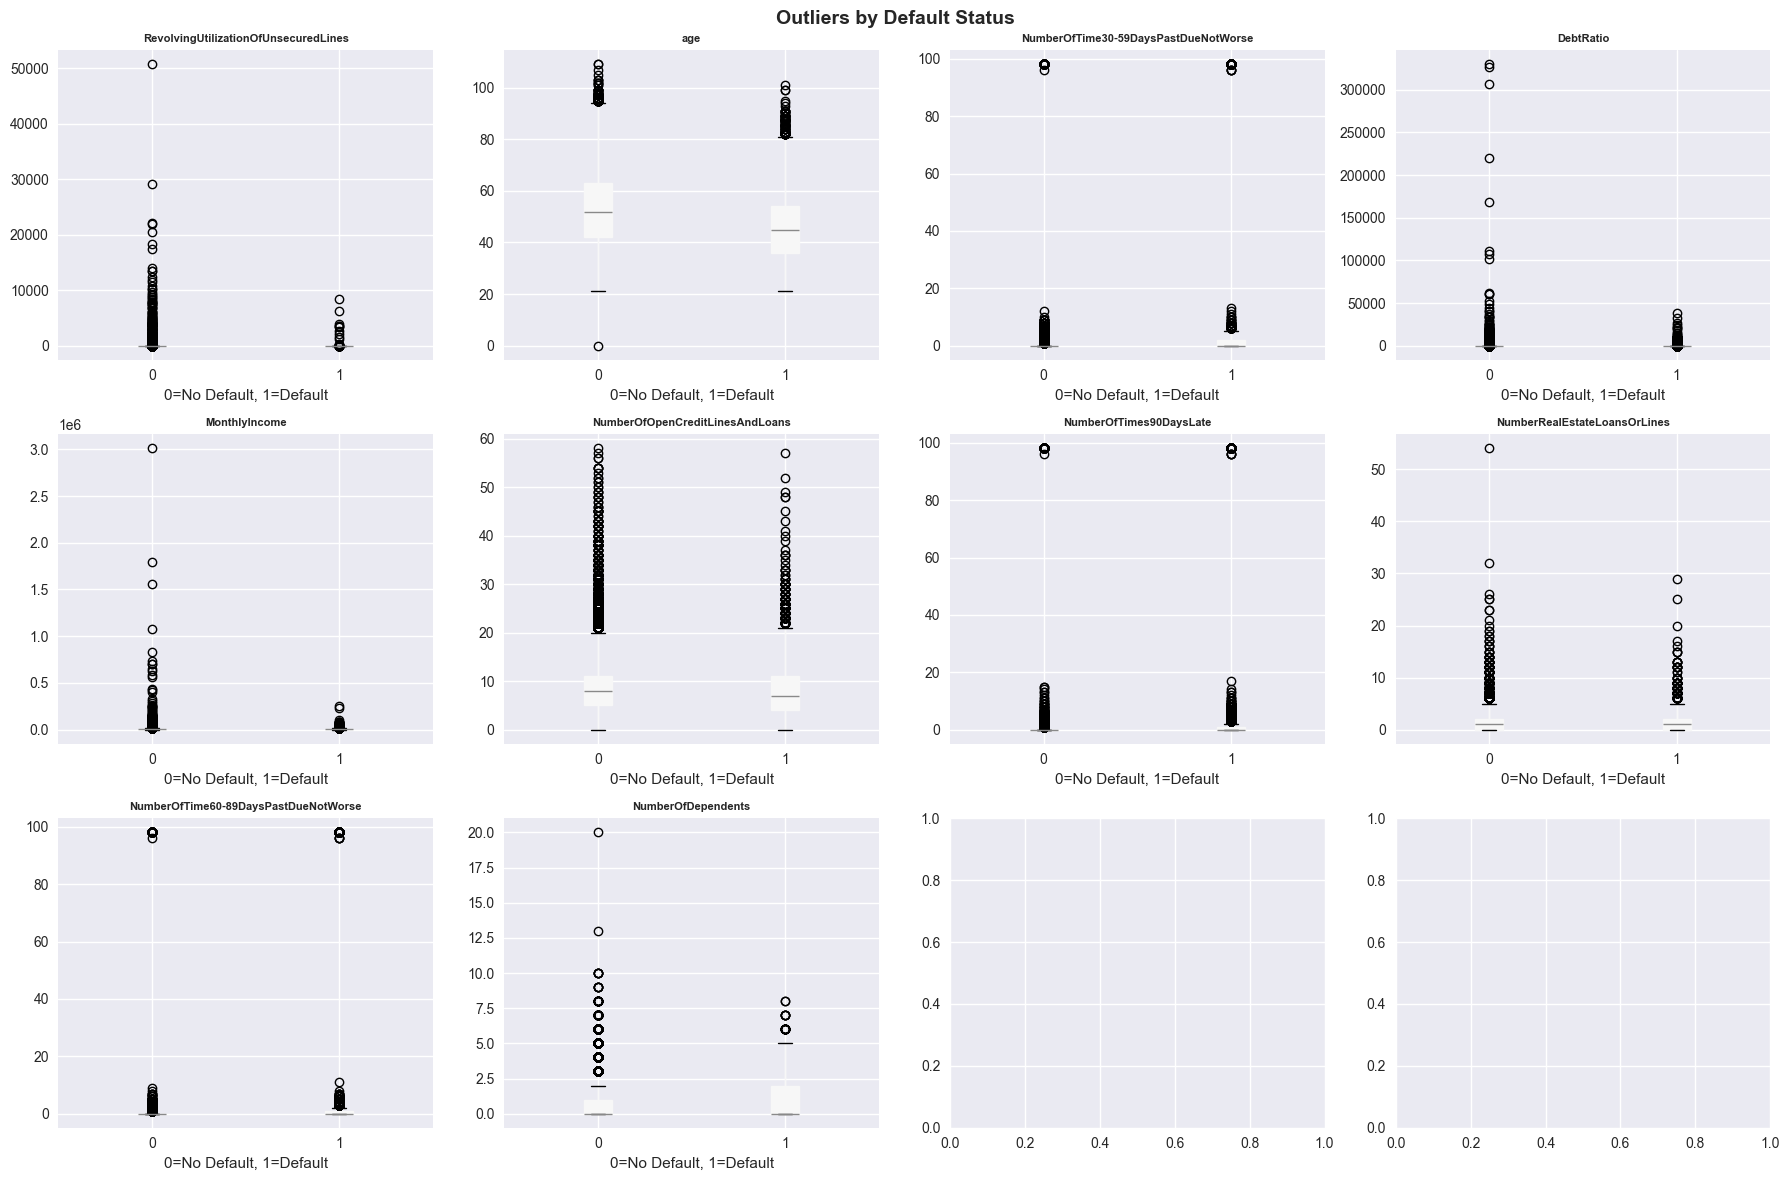

In [11]:
# ============================================
# CELL 8: Outlier Detection — Box Plots
# ============================================

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    # Default vs Non-default alag rang mein
    df.boxplot(
        column=col,
        by='SeriousDlqin2yrs',
        ax=axes[i],
        patch_artist=True
    )
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].set_xlabel('0=No Default, 1=Default')

plt.suptitle('Outliers by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/boxplots.png', dpi=150)
plt.show()

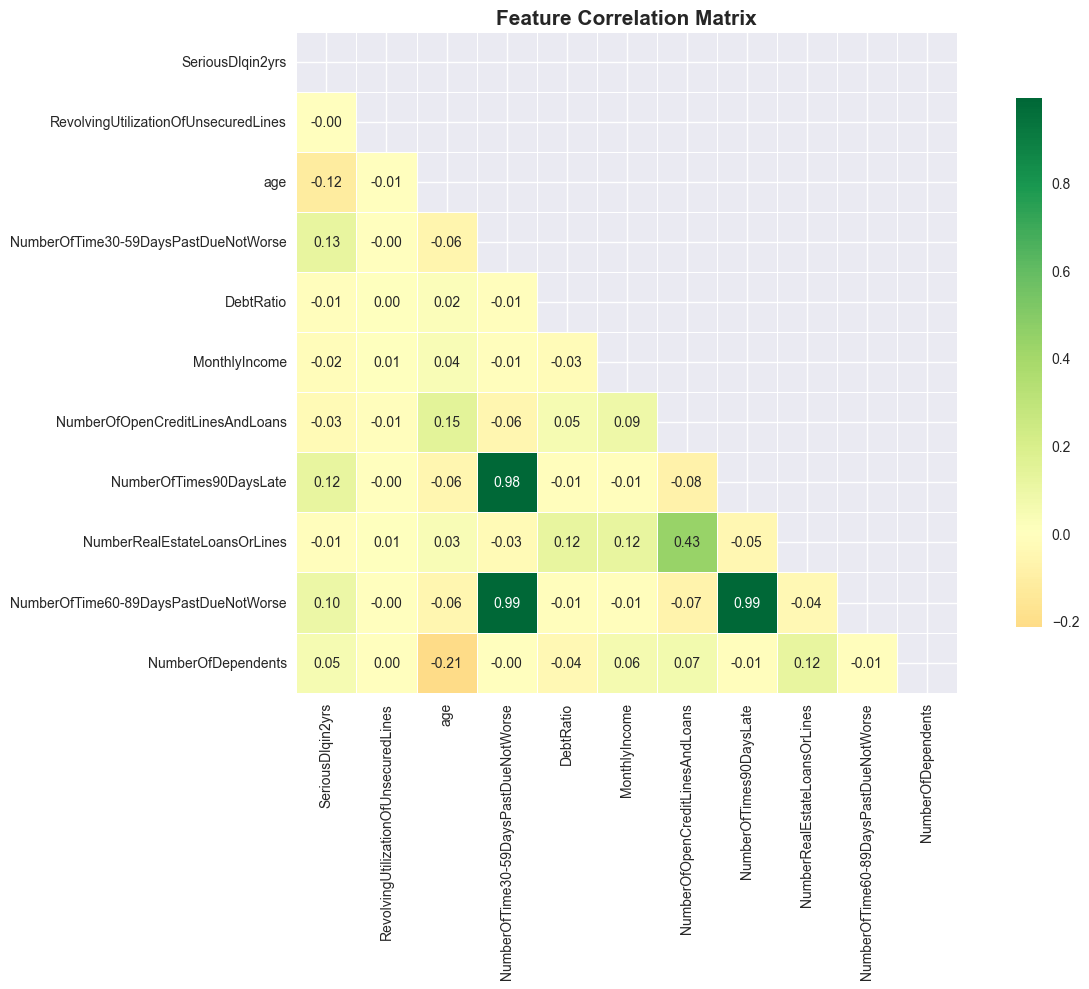

In [35]:
# ============================================
# CELL 9: Correlation Heatmap
# ============================================

# WHY? Highly correlated features = redundant info
# Multicollinearity model ko confuse karta hai

plt.figure(figsize=(14, 10))

corr_matrix = df.corr()

# Mask for upper triangle (symmetrical hoti hai)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/correlation.png', dpi=150)
plt.show()

# -----------------------------------------------
# Key Insights:
# - 3 late payment columns are highly correlated (0.9+)
# - We'll combine them into TotalLatePayments
# -----------------------------------------------

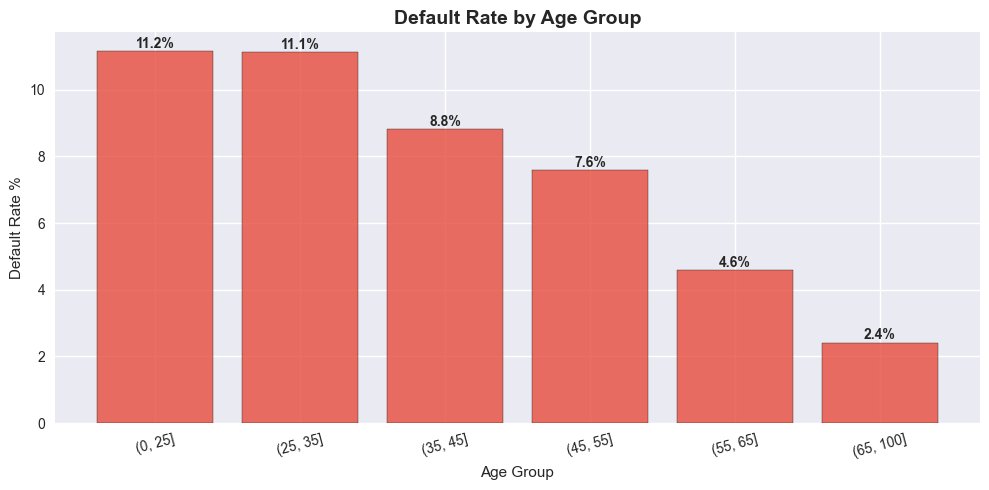

In [36]:
# ============================================
# CELL 10: Age vs Default Rate Analysis
# ============================================

# Real business insight nikalo!
# Bank managers yehi dekhte hain

age_bins = pd.cut(df['age'], bins=[0,25,35,45,55,65,100])
age_default = df.groupby(age_bins)['SeriousDlqin2yrs'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(
    range(len(age_default)),
    age_default.values,
    color='#e74c3c',
    alpha=0.8,
    edgecolor='black'
)
plt.xticks(range(len(age_default)), age_default.index, rotation=15)
plt.title('Default Rate by Age Group', fontsize=14, fontweight='bold')
plt.ylabel('Default Rate %')
plt.xlabel('Age Group')

for bar, val in zip(bars, age_default.values):
    plt.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# -----------------------------------------------
# Insight: Young age group (< 25) highest default rate
# This becomes a powerful feature!
# -----------------------------------------------